In [1]:
import sys
print(sys.executable)

/opt/anaconda3/envs/finalnlp/bin/python


In [ ]:
#pip install datasets

In [2]:
import torch

In [3]:
import pandas as pd
import numpy as np
from datasets import load_dataset

### Loading ade_corpus_v2_drug_ade_relation dataset

In [15]:
ds_drug_ade = load_dataset("ade-benchmark-corpus/ade_corpus_v2", "Ade_corpus_v2_drug_ade_relation")

In [16]:
print(ds_drug_ade)

DatasetDict({
    train: Dataset({
        features: ['text', 'drug', 'effect', 'indexes'],
        num_rows: 6821
    })
})


In [17]:
train_df_drug_ade = pd.DataFrame(ds_drug_ade['train'][:])
train_df_drug_ade.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6821 entries, 0 to 6820
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     6821 non-null   object
 1   drug     6821 non-null   object
 2   effect   6821 non-null   object
 3   indexes  6821 non-null   object
dtypes: object(4)
memory usage: 213.3+ KB


In [18]:
train_df_drug_ade.head()

,text,drug,effect,indexes
0,Intravenous azithromycin-induced ototoxicity.,azithromycin,ototoxicity,"{'drug': {'start_char': [12], 'end_char': [24]..."
1,"Immobilization, while Paget's bone disease was...",dihydrotachysterol,increased calcium-release,"{'drug': {'start_char': [91], 'end_char': [109..."
2,Unaccountable severe hypercalcemia in a patien...,dihydrotachysterol,hypercalcemia,"{'drug': {'start_char': [84], 'end_char': [102..."
3,METHODS: We report two cases of pseudoporphyri...,naproxen,pseudoporphyria,"{'drug': {'start_char': [58], 'end_char': [66]..."
4,METHODS: We report two cases of pseudoporphyri...,oxaprozin,pseudoporphyria,"{'drug': {'start_char': [71], 'end_char': [80]..."


In [19]:
# Apply lowercase to all string (object) columns only
train_df_drug_ade = train_df_drug_ade.applymap(lambda x: x.lower() if isinstance(x, str) else x)
train_df_drug_ade.head()

/var/folders/1b/d9_0wtds5rv483npfy_brzqh0000gn/T/ipykernel_35518/4191252377.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  train_df_drug_ade = train_df_drug_ade.applymap(lambda x: x.lower() if isinstance(x, str) else x)


,text,drug,effect,indexes
0,intravenous azithromycin-induced ototoxicity.,azithromycin,ototoxicity,"{'drug': {'start_char': [12], 'end_char': [24]..."
1,"immobilization, while paget's bone disease was...",dihydrotachysterol,increased calcium-release,"{'drug': {'start_char': [91], 'end_char': [109..."
2,unaccountable severe hypercalcemia in a patien...,dihydrotachysterol,hypercalcemia,"{'drug': {'start_char': [84], 'end_char': [102..."
3,methods: we report two cases of pseudoporphyri...,naproxen,pseudoporphyria,"{'drug': {'start_char': [58], 'end_char': [66]..."
4,methods: we report two cases of pseudoporphyri...,oxaprozin,pseudoporphyria,"{'drug': {'start_char': [71], 'end_char': [80]..."


In [20]:
train_df_drug_ade = train_df_drug_ade[['drug','effect']]
train_df_drug_ade.head()

,drug,effect
0,azithromycin,ototoxicity
1,dihydrotachysterol,increased calcium-release
2,dihydrotachysterol,hypercalcemia
3,naproxen,pseudoporphyria
4,oxaprozin,pseudoporphyria


In [21]:
# Check missing values per column
print(train_df_drug_ade.isnull().sum())

drug      0
effect    0
dtype: int64


In [22]:
train_df_drug_ade.tail()

,drug,effect
6816,lithium,lithium intoxication
6817,lithium,lithium intoxication
6818,clozapine,eosinophilia
6819,clozapine,eosinophilia
6820,clozapine,eosinophilia


### Checking for duplicates and remove

In [23]:
# See how many duplicate drug-effect pairs exist
duplicate_rows = train_df_drug_ade.duplicated(subset=['drug', 'effect'])

# Print how many
print(f"Number of duplicate drug-effect rows: {duplicate_rows.sum()}")

Number of duplicate drug-effect rows: 1656


In [25]:
# Remove duplicates based on drug and effect columns
train_df_drug_ade = train_df_drug_ade.drop_duplicates(subset=['drug', 'effect'])

# Reset index (optional, for clean numbering)
train_df_drug_ade = train_df_drug_ade.reset_index(drop=True)

In [26]:
train_df_drug_ade.tail()

,drug,effect
5160,psoralen,sunburn
5161,metoclopramide,nonthrombocytopenic vascular-type palpable pur...
5162,metoclopramide,nonthrombocytopenic palpable purpura
5163,lithium,diabetes insipidus-like syndrome
5164,lithium,lithium intoxication


In [28]:
# Check shape
print(f"Shape of dataset: {train_df_drug_ade.shape}")

Shape of dataset: (5165, 2)


### Change row numer 200 here

In [29]:
# Select first 200
#small_df = train_df_drug_ade[['drug', 'effect']].head(500).copy()
small_df = train_df_drug_ade[['drug', 'effect']].copy()
# Rename to match
small_df = small_df.rename(columns={'drug': 'drugname', 'effect': 'pt'})

#Tokenize drugname and pt by splitting commas
small_df['drugname'] = small_df['drugname'].str.lower().str.split(', ')
small_df['pt'] = small_df['pt'].str.lower().str.split(', ')

# Check
print(small_df.head())

               drugname                           pt
0        [azithromycin]                [ototoxicity]
1  [dihydrotachysterol]  [increased calcium-release]
2  [dihydrotachysterol]              [hypercalcemia]
3            [naproxen]            [pseudoporphyria]
4           [oxaprozin]            [pseudoporphyria]


#### MultiLabelBinarizer

In [30]:
from sklearn.preprocessing import MultiLabelBinarizer

#Initialize MultiLabelBinarizer
mlb = MultiLabelBinarizer()

In [31]:
#Fit and transform the 'pt' column
encoded_pts = mlb.fit_transform(small_df['pt'])

#Save the effect names
pt_columns = mlb.classes_

#Check
print(f"Shape of encoded_pt: {encoded_pts.shape}")
print(f"Some classes: {pt_columns[:10]}")  # Display first 10 effect labels

Shape of encoded_pt: (5165, 3006)
Some classes: ['"cotton-wool" spots' '(sub)fulminant hepatitis' '100 mg/m2'
 '15-kg weight gain'
 '8-hydroacy-desmethylclomipramine plasma level decrease'
 'a pruritic desquamating erythrodermic rash' 'aa' 'abdominal cramping'
 'abdominal pain' 'abdominal right lower quadrant pain']


### Prepare Inputs and Targets

In [32]:
# Combine drug and effect into a single text input
small_df['input_text'] = small_df['drugname'].apply(lambda x: " ".join(x)) + " " + small_df['pt'].apply(lambda x: " ".join(x))

# No need to split now since we used MultiLabelBinarizer already for multilabels
# (Your label array is already encoded separately)

# Just check the input_text
print(small_df[['input_text']].head())

                                     input_text
0                      azithromycin ototoxicity
1  dihydrotachysterol increased calcium-release
2              dihydrotachysterol hypercalcemia
3                      naproxen pseudoporphyria
4                     oxaprozin pseudoporphyria


### Create Dataset Class

In [33]:
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer

# Load ClinicalBERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

class DrugEffectDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        # Tokenize the input text
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.float)  # Important: float for BCEWithLogitsLoss
        }


#### Create DataLoaders

In [34]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# 1. Split into train and validation
train_texts, val_texts, train_labels, val_labels = train_test_split(
    small_df['input_text'].tolist(),
    encoded_pts,
    test_size=0.2,
    random_state=42
)

# 2. Create Dataset objects
train_dataset = DrugEffectDataset(train_texts, train_labels, tokenizer)
val_dataset = DrugEffectDataset(val_texts, val_labels, tokenizer)

# 3. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")


Training samples: 4132
Validation samples: 1033


### Load ClinicalBERT Model for Multi-Label Classification

#### Code to Load ClinicalBERT

In [35]:
from transformers import AutoModelForSequenceClassification

# How many effect labels to predict
num_labels = encoded_pts.shape[1]
print(f"Number of effect labels: {num_labels}")

# Load ClinicalBERT model with correct output size
model = AutoModelForSequenceClassification.from_pretrained(
    "emilyalsentzer/Bio_ClinicalBERT",
    num_labels=num_labels,
    problem_type="multi_label_classification"
)

# Move model to device
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"Model loaded on {device}")


Number of effect labels: 3006


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded on cpu


#### Full Training Code

In [36]:
from torch import nn
from torch.optim import AdamW
from tqdm import tqdm

# Define optimizer and loss
optimizer = AdamW(model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()

epochs = 10

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    # Training
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    train_bar = tqdm(train_loader, desc="Training", leave=False)

    for batch in train_bar:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = (torch.sigmoid(logits) > 0.5).float()  # multi-label threshold 0.5
        train_correct += (preds == labels).float().mean().item()
        train_total += 1

        train_bar.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = train_correct / train_total
    print(f"Train Loss: {avg_train_loss:.4f} | Train Accuracy: {avg_train_acc:.4f}")

    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    val_bar = tqdm(val_loader, desc="Validation", leave=False)

    with torch.no_grad():
        for batch in val_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            loss = criterion(logits, labels)
            val_loss += loss.item()

            preds = (torch.sigmoid(logits) > 0.5).float()
            val_correct += (preds == labels).float().mean().item()
            val_total += 1

            val_bar.set_postfix(loss=loss.item())

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = val_correct / val_total
    print(f"Validation Loss: {avg_val_loss:.4f} | Validation Accuracy: {avg_val_acc:.4f}")



Epoch 1/10


Train Loss: 0.0373 | Train Accuracy: 0.9919


Validation Loss: 0.0040 | Validation Accuracy: 0.9997

Epoch 2/10


KeyboardInterrupt: 

#### Make Predictions on New Data

In [27]:
# Switch model to eval mode
model.eval()

# Pick a random sample from validation set
sample_idx = 3  # You can change this number: 0, 1, 2, etc.

# Prepare input
text = val_texts[sample_idx]
inputs = tokenizer(
    text,
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=128
).to(device)

# Get model prediction
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    probs = torch.sigmoid(logits).squeeze(0)  # shape (num_labels,)

# Thresholding: if probability > 0.5, consider it predicted
predicted_indices = (probs > 0.5).nonzero(as_tuple=True)[0].tolist()

# Decode predicted label indices to actual effect names
predicted_effects = [pt_columns[i] for i in predicted_indices]

# Ground truth
true_effects = [pt_columns[i] for i in (val_labels[sample_idx].nonzero()[0].tolist())]

# Show results
print(f"Input: {text}")
print(f"\nPredicted Effects: {predicted_effects}")
print(f"\nTrue Effects: {true_effects}")


Input: clozapine elevated serum triglycerides

Predicted Effects: []

True Effects: ['elevated serum triglycerides']


#### confusion matrix

In [28]:
#!pip install seaborn

### Baseline checking

In [81]:
# 1. Find the most common effects
effect_counts = encoded_pts.sum(axis=0)

# Get top N effects
top_n = 5  # You can try top 3, 5, 10 based on how strict you want
top_indices = effect_counts.argsort()[-top_n:][::-1]

# Map indices to effect names
top_effects = [pt_columns[i] for i in top_indices]
print(f"Top {top_n} most common effects:", top_effects)


Top 5 most common effects: ['neurotoxicity', 'seizures', 'hypocalcemic tetany', 'incontinence', 'hepatitis']


In [82]:
# Now simulate always predicting these top N effects for every input.
import numpy as np

# 2. Simulate baseline predictions
baseline_preds = np.zeros_like(val_labels)

for idx in top_indices:
    baseline_preds[:, idx] = 1  # Predict these effects for every sample

# 3. Evaluate
from sklearn.metrics import accuracy_score, f1_score, hamming_loss

# Hamming Loss: lower is better
hamming = hamming_loss(val_labels, baseline_preds)

# Micro and Macro F1
f1_micro = f1_score(val_labels, baseline_preds, average='micro')
f1_macro = f1_score(val_labels, baseline_preds, average='macro')

print(f"\nHamming Loss (baseline): {hamming:.4f}")
print(f"F1 Micro (baseline): {f1_micro:.4f}")
print(f"F1 Macro (baseline): {f1_macro:.4f}")



Hamming Loss (baseline): 0.0147
F1 Micro (baseline): 0.0132
F1 Macro (baseline): 0.0002


/opt/anaconda3/envs/finalnlp/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [70]:
# Calculate imbalance
import numpy as np

# If all_labels is a list, convert to numpy array
all_labels_array = np.array(all_labels)

# Calculate
total = all_labels_array.size
positive = all_labels_array.sum()
negative = total - positive

print(f"Positive samples: {positive} ({positive/total:.4f}%)")
print(f"Negative samples: {negative} ({negative/total:.4f}%)")

Positive samples: 106.0 (0.0026%)
Negative samples: 40594.0 (0.9974%)


In [71]:
print(all_labels)
print(len(all_labels))

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
100


### New validation code

### new code

In [84]:
# -----------------------
# Optimizer, Loss, and Epochs
# -----------------------
from torch.optim import AdamW
import torch.nn as nn

from tqdm import tqdm
import torch
import torch.nn as nn
from torch.optim import AdamW

# Define optimizer
optimizer = AdamW(model.parameters(),lr = 5e-5) #lr=1e-4 before

# Weighted loss to handle class imbalance
pos_weight = torch.tensor([5.0]).to(device)  # Weight positive class 5x
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

epochs = 5  # or any number you want

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    # Training
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    train_bar = tqdm(train_loader, desc="Training", leave=False)

    for batch in train_bar:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = (torch.sigmoid(logits) > 0.3).float()  # LOWER THRESHOLD = 0.3
        train_correct += (preds == labels).float().mean().item()
        train_total += 1

        train_bar.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = train_correct / train_total
    print(f"Train Loss: {avg_train_loss:.4f} | Train Accuracy: {avg_train_acc:.4f}")

    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    val_bar = tqdm(val_loader, desc="Validation", leave=False)

    with torch.no_grad():
        for batch in val_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            loss = criterion(logits, labels)
            val_loss += loss.item()

            preds = (torch.sigmoid(logits) > 0.3).float()  # LOWER THRESHOLD = 0.3
            val_correct += (preds == labels).float().mean().item()
            val_total += 1

            val_bar.set_postfix(loss=loss.item())

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = val_correct / val_total
    print(f"Validation Loss: {avg_val_loss:.4f} | Validation Accuracy: {avg_val_acc:.4f}")



Epoch 1/5


Train Loss: 0.0669 | Train Accuracy: 0.9975


Validation Loss: 0.0928 | Validation Accuracy: 0.9974

Epoch 2/5


Train Loss: 0.0655 | Train Accuracy: 0.9975


Validation Loss: 0.1048 | Validation Accuracy: 0.9974

Epoch 3/5


...

Validation Loss: 0.1092 | Validation Accuracy: 0.9974

Epoch 4/5


Train Loss: 0.0647 | Train Accuracy: 0.9975


Validation Loss: 0.1129 | Validation Accuracy: 0.9974

Epoch 5/5


Train Loss: 0.0646 | Train Accuracy: 0.9975


Validation Loss: 0.1114 | Validation Accuracy: 0.9974


### Checking

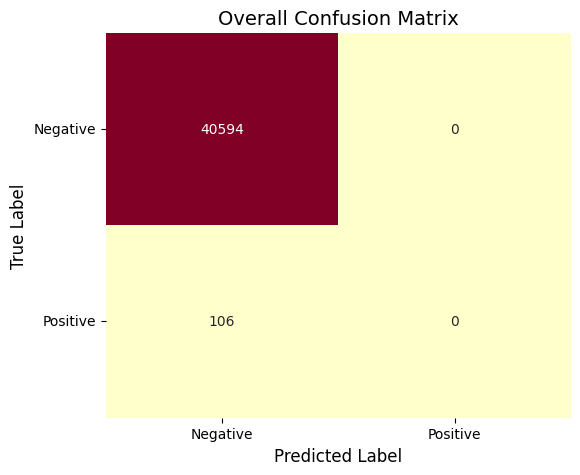

In [69]:
# -----------------------
# Confusion Matrix
# -----------------------

from sklearn.metrics import multilabel_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate multilabel confusion matrix
conf_matrices = multilabel_confusion_matrix(all_labels, all_preds)

# Sum over all classes
tp = conf_matrices[:, 1, 1]
fn = conf_matrices[:, 1, 0]
fp = conf_matrices[:, 0, 1]
tn = conf_matrices[:, 0, 0]

# Overall confusion matrix
overall_conf_matrix = np.array([
    [tn.sum(), fp.sum()],
    [fn.sum(), tp.sum()]
])

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(overall_conf_matrix, annot=True, fmt="d", cmap="YlOrRd", cbar=False)
plt.title('Overall Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks([0.5, 1.5], ['Negative', 'Positive'], fontsize=10)
plt.yticks([0.5, 1.5], ['Negative', 'Positive'], rotation=0, fontsize=10)
plt.show()


### Trying with dropout

In [112]:
# ✅ Setup and Model Definition
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer
from torch.optim import AdamW

class ClinicalBERTClassifier(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super(ClinicalBERTClassifier, self).__init__()
        self.bert = AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]  # CLS token
        pooled_output = self.dropout(pooled_output)
        return self.classifier(pooled_output)

# Instantiate model
model = ClinicalBERTClassifier(dropout_rate=0.3)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

In [ ]:
# 4. Compute pos_weight from your label matrix (once)
# (Assuming you have `encoded_pts` with shape [num_samples, num_labels])
#multi hot-label encoding
label_counts = encoded_pts.sum(axis=0)
total_counts = encoded_pts.shape[0]
#pos_weight = (total_counts - label_counts) / (label_counts + 1e-5)
#pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float).to(device)

## Compute pos_weight for loss function
# Assuming encoded_pts is your label matrix: shape [num_samples, num_labels]
label_sums = encoded_pts.sum(axis=0)
total_samples = encoded_pts.shape[0]

epsilon = 1e-8  # to avoid division by zero
pos_weights = (total_samples - label_sums) / (label_sums + epsilon)
pos_weights = torch.tensor(pos_weights, dtype=torch.float32).to(device)


# 5. Define Loss and Optimizer
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer = AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)

print("✅ ClinicalBERT model initialized and ready.")

✅ ClinicalBERT model initialized and ready.


#

### 

### Training

In [109]:
from tqdm import tqdm

epochs = 5
threshold = 0.3  # can tune later

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs} — Training")
    
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    train_bar = tqdm(train_loader, desc="Training", leave=False)

    for batch in train_bar:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = (torch.sigmoid(logits) > threshold).float()
        train_correct += (preds == labels).float().mean().item()
        train_total += 1

        train_bar.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = train_correct / train_total
    print(f"Train Loss: {avg_train_loss:.4f} | Train Accuracy: {avg_train_acc:.4f}")



Epoch 1/5 — Training


Train Loss: 1.4403 | Train Accuracy: 0.0351

Epoch 2/5 — Training


Train Loss: 1.4550 | Train Accuracy: 0.0942

Epoch 3/5 — Training


Train Loss: 1.4173 | Train Accuracy: 0.1479

Epoch 4/5 — Training


Train Loss: 1.3857 | Train Accuracy: 0.1656

Epoch 5/5 — Training


Train Loss: 1.3743 | Train Accuracy: 0.1577


#### Validation

In [110]:
from sklearn.metrics import f1_score, hamming_loss, classification_report

print(f"\nEpoch {epoch+1} — Validation")

model.eval()
val_loss = 0
val_correct = 0
val_total = 0

all_preds = []
all_labels = []

val_bar = tqdm(val_loader, desc="Validation", leave=False)

with torch.no_grad():
    for batch in val_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].cpu().numpy()

        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs > threshold).astype(int)

        all_preds.append(preds)
        all_labels.append(labels)

        val_loss += criterion(torch.tensor(probs), torch.tensor(labels)).item()
        val_correct += (preds == labels).mean()
        val_total += 1

avg_val_loss = val_loss / len(val_loader)
avg_val_acc = val_correct / val_total
print(f"Validation Loss: {avg_val_loss:.4f} | Validation Accuracy: {avg_val_acc:.4f}")

# Evaluation metrics
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

f1_micro = f1_score(all_labels, all_preds, average='micro', zero_division=0)
f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
hamming = hamming_loss(all_labels, all_preds)

print("\n📊 Evaluation Metrics:")
print(f"F1 Micro: {f1_micro:.4f} | F1 Macro: {f1_macro:.4f} | Hamming Loss: {hamming:.4f}")
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, zero_division=0))



Epoch 5 — Validation


Validation Loss: 1.5586 | Validation Accuracy: 0.1473

📊 Evaluation Metrics:
F1 Micro: 0.0003 | F1 Macro: 0.0003 | Hamming Loss: 0.8527

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         0
           7       0.00      1.00      0.00         1
           8       0.00      1.00      0.00         1
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         0
          11       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         0
          13       0.00      0.00      0.00         0
          14       0.00     

In [86]:
from torch.optim import AdamW

In [107]:
from sklearn.metrics import (
    hamming_loss,
    f1_score,
    precision_score,
    recall_score,
    classification_report
)

# Make sure your predictions and labels are NumPy arrays
# all_preds, all_labels = np.vstack([...]), np.vstack([...]) ← you already did this

# 1. F1-Scores
f1_micro = f1_score(all_labels, all_preds, average='micro', zero_division=0)
f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)

# 2. Hamming Loss
hamming = hamming_loss(all_labels, all_preds)

# 3. Per-label Precision, Recall, F1
print("\n🔍 Per-label Precision / Recall / F1-Score:")
report = classification_report(all_labels, all_preds, zero_division=0)
print(report)

# 4. Summary
print("\n✅ Overall Evaluation Metrics:")
print(f"F1 Score (Micro): {f1_micro:.4f}")
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"Hamming Loss    : {hamming:.4f}")



🔍 Per-label Precision / Recall / F1-Score:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         0
          11       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         0
          13       0.00      0.00      0.00         0
          14       0.00      0.00      0.00         2
          15       0.00      0.00      0.00         0
          16       0.00      0.00    

### Confusion matrix

/opt/anaconda3/envs/finalnlp/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


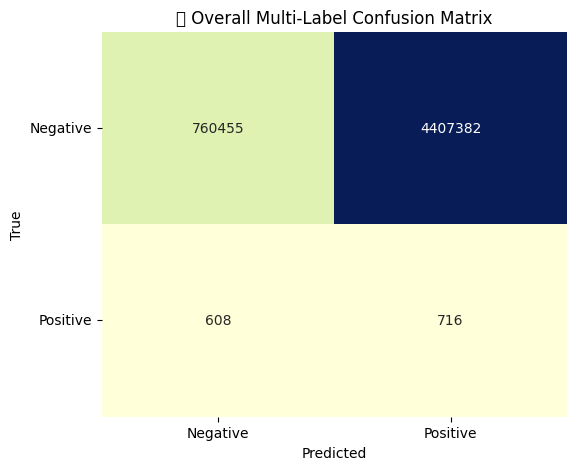

In [111]:
from sklearn.metrics import multilabel_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create multilabel confusion matrices
conf_matrices = multilabel_confusion_matrix(all_labels, all_preds)

# Aggregate to get overall confusion matrix
tp = conf_matrices[:, 1, 1].sum()
fp = conf_matrices[:, 0, 1].sum()
fn = conf_matrices[:, 1, 0].sum()
tn = conf_matrices[:, 0, 0].sum()

overall_cm = np.array([[tn, fp],
                       [fn, tp]])

# Plot confusion matrix heatmap
plt.figure(figsize=(6,5))
sns.heatmap(overall_cm, annot=True, fmt="d", cmap="YlGnBu", cbar=False)
plt.title("🧠 Overall Multi-Label Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0.5, 1.5], ['Negative', 'Positive'])
plt.yticks([0.5, 1.5], ['Negative', 'Positive'], rotation=0)
plt.show()
